# Steam Pipeline — Dashboard

Análise dos top 100 jogos da Steam: avaliações, gêneros e jogos relacionados por co-menção nas reviews.

Dados gerados pelo pipeline: `ingestion/` → `transform/` → `gold/`.

In [1]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt

games = pd.read_csv("silver/games.csv")
review_summaries = pd.read_csv("silver/review_summaries.csv")
top_by_score = pd.read_csv("gold/top_games_by_score.csv")
top_by_volume = pd.read_csv("gold/top_games_by_volume.csv")
genre_stats = pd.read_csv("gold/genre_stats.csv")
comentions = pd.read_csv("gold/comentions.csv")

plt.rcParams["figure.facecolor"] = "white"

## Visão geral dos dados

100 jogos, com metadados (gênero, preço, plataforma) e avaliações de jogadores.

In [2]:
games.head()

,appid,name,type,is_free,developer,publisher,genres,on_windows,on_mac,on_linux,release_date,release_year,metacritic_score,price_usd,price_original_usd,discount_percent,required_age,short_description
0,730,Counter-Strike 2,game,1,Valve,Valve,Action | Free To Play,1,0,1,"Aug 21, 2012",2012.0,NaN,NaN,NaN,NaN,0,"For over two decades, Counter-Strike has offer..."
1,1172470,Apex Legends™,game,1,Respawn,Electronic Arts,Action | Adventure | Free To Play,1,0,0,"Nov 4, 2020",2020.0,88.0,NaN,NaN,NaN,0,"Apex Legends is the award-winning, free-to-pla..."
2,578080,PUBG: BATTLEGROUNDS,game,1,PUBG Corporation,"KRAFTON, Inc.",Action | Adventure | Massively Multiplayer | F...,1,0,0,"Dec 21, 2017",2017.0,NaN,NaN,NaN,NaN,13,"PUBG: BATTLEGROUNDS, the high-stakes winner-ta..."
3,1623730,Palworld,game,0,Pocketpair,Pocketpair,Action | Adventure | Indie | RPG | Early Access,1,0,0,"Jan 18, 2024",2024.0,NaN,29.99,29.99,0.0,0,"Fight, farm, build and work alongside mysterio..."
4,440,Team Fortress 2,game,1,Valve,Valve,Action | Free To Play,1,0,1,"Oct 10, 2007",2007.0,92.0,NaN,NaN,NaN,0,Nine distinct classes provide a broad range of...


## Top 20 jogos por avaliação positiva

Apenas jogos com no mínimo 1.000 reviews, para evitar que jogos com poucas avaliações dominem o ranking.

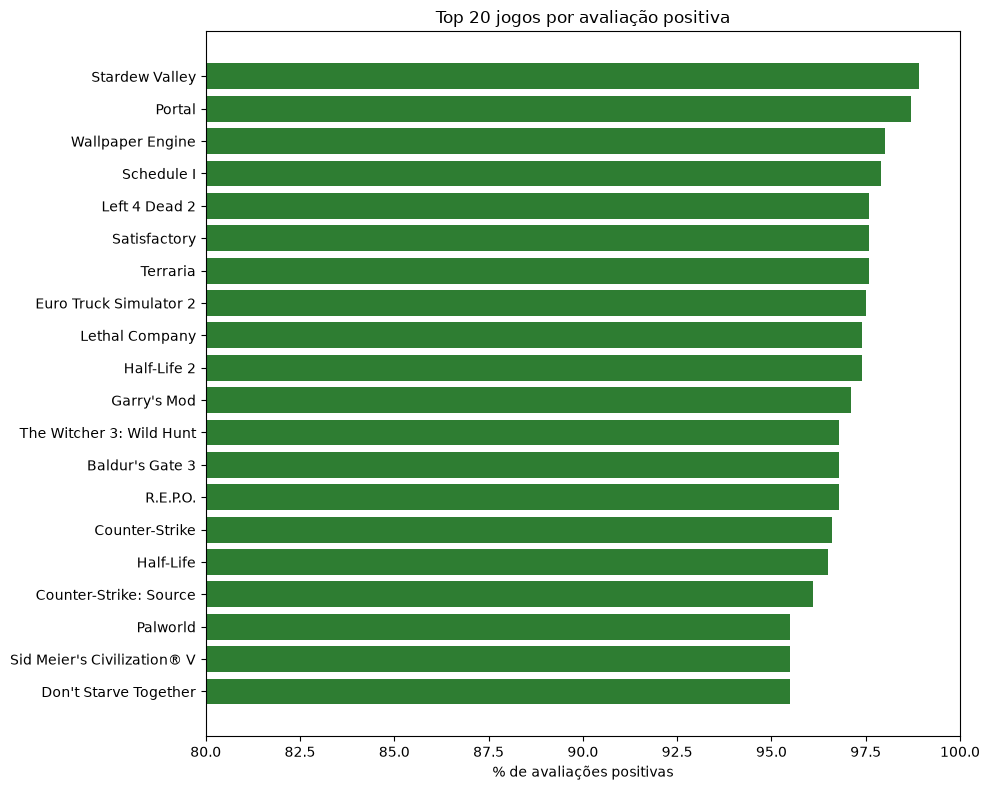

In [3]:
data = top_by_score.sort_values("positive_ratio")

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(data["name"], data["positive_ratio"], color="#2e7d32")
ax.set_xlabel("% de avaliações positivas")
ax.set_title("Top 20 jogos por avaliação positiva")
ax.set_xlim(80, 100)
plt.tight_layout()
plt.show()

## Top 20 jogos por volume de reviews

Quais jogos têm a maior base de jogadores avaliando.

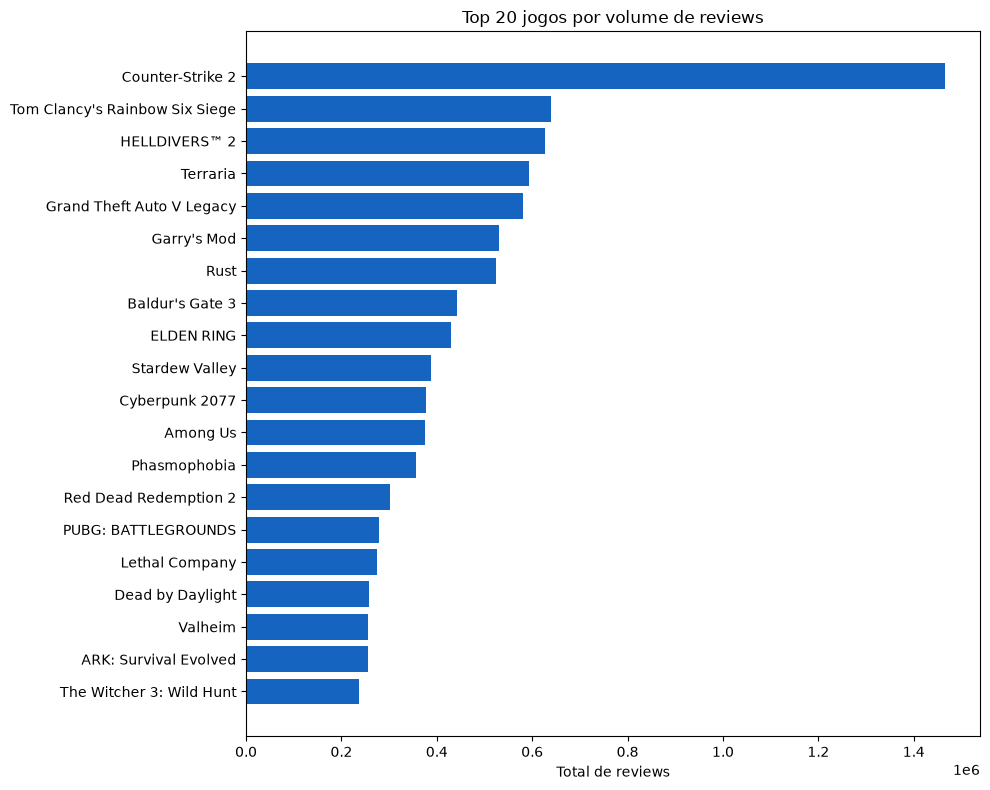

In [4]:
data = top_by_volume.sort_values("total_reviews")

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(data["name"], data["total_reviews"], color="#1565c0")
ax.set_xlabel("Total de reviews")
ax.set_title("Top 20 jogos por volume de reviews")
plt.tight_layout()
plt.show()

## Avaliação média por gênero

Quais gêneros têm, em média, os jogos mais bem avaliados.

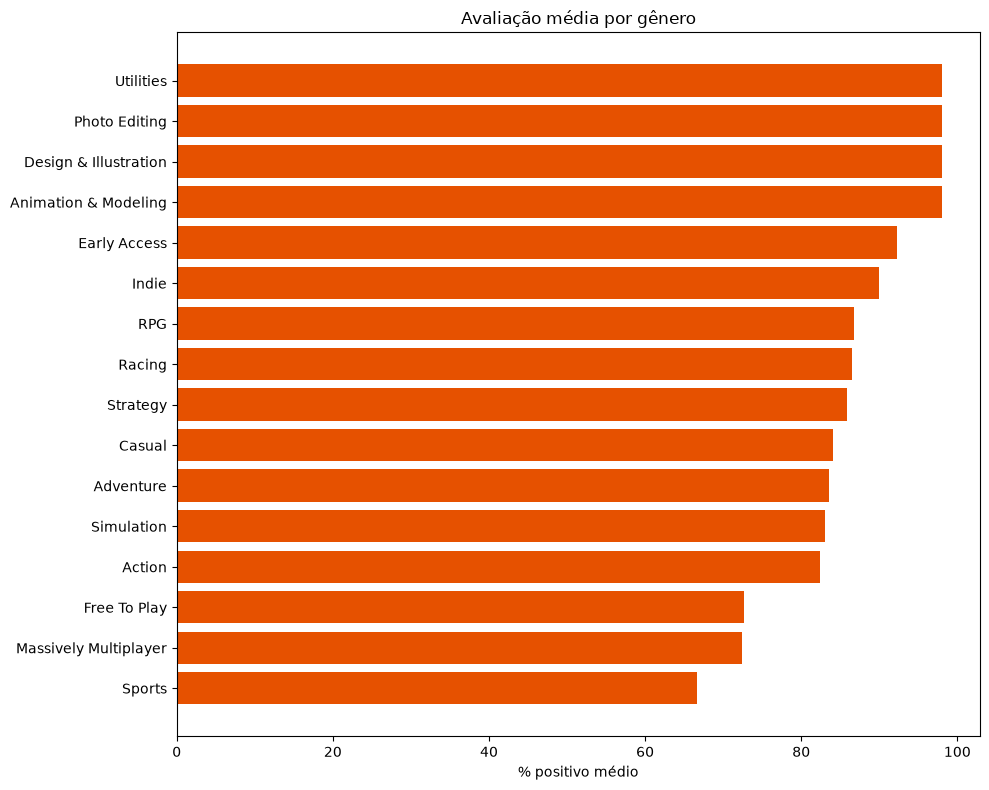

In [5]:
data = genre_stats.sort_values("avg_positive_ratio")

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(data["genre"], data["avg_positive_ratio"], color="#e65100")
ax.set_xlabel("% positivo médio")
ax.set_title("Avaliação média por gênero")
plt.tight_layout()
plt.show()

## Jogos relacionados (co-menções nas reviews)

Quando jogadores de um jogo mencionam outro jogo na review, é um sinal de similaridade — geralmente sequências, concorrentes diretos ou jogos do mesmo estilo.

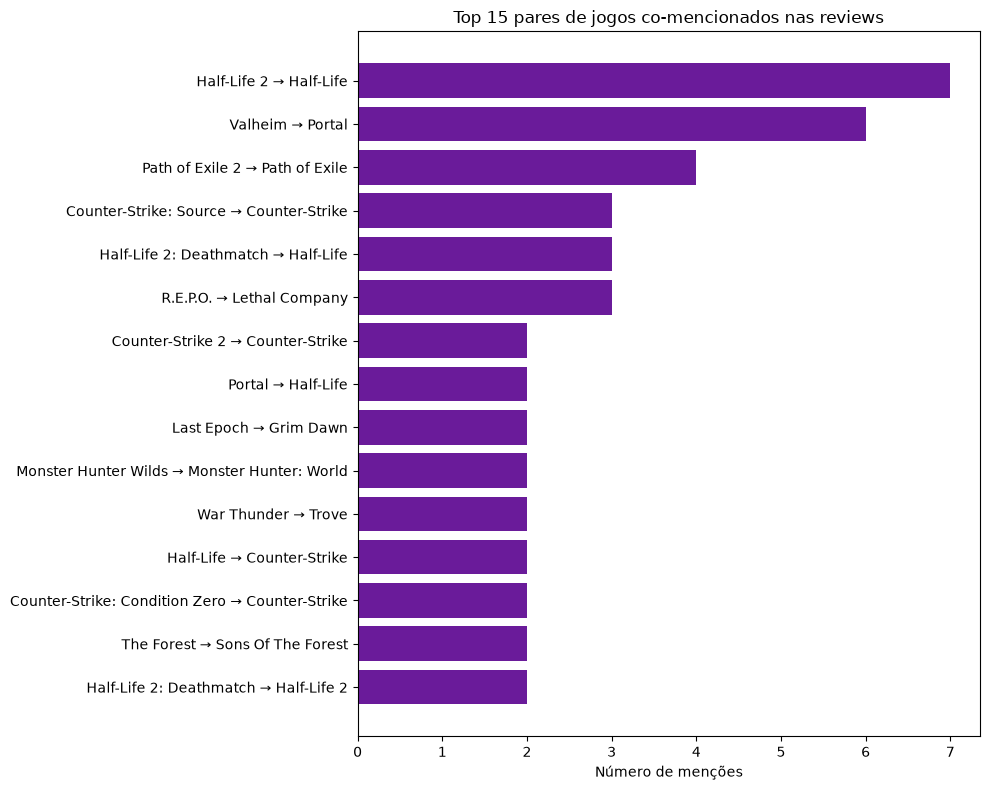

In [6]:
data = comentions.sort_values("mention_count").tail(15)
labels = data["source_name"] + " → " + data["mentioned_name"]

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(labels, data["mention_count"], color="#6a1b9a")
ax.set_xlabel("Número de menções")
ax.set_title("Top 15 pares de jogos co-mencionados nas reviews")
plt.tight_layout()
plt.show()